In [6]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import random

from ase import Atoms, units
from ase.io import read, write, Trajectory
from ase import units
# from mace.calculators import MACECalculator
from ase.data import chemical_symbols

# from tensorpotential.calculator import TPCalculator
# from tensorpotential.calculator.foundation_models import grace_fm
import pandas as pd
from rdkit import Chem
import os
import math
# from sklearn.metrics import r2_score
# import seaborn as sns
# from sklearn.metrics import mean_squared_error, root_mean_squared_error

In [9]:
grace_errors_1l_off_s = pd.read_csv("error_files/grace_errors_b_off_1l_small.csv")
grace_errors_1l_off_m = pd.read_csv("error_files/grace_errors_b_off_1l_medium.csv")
grace_errors_1l_off_l = pd.read_csv("error_files/grace_errors_b_off_1l_large.csv")
grace_errors_2l_off_s = pd.read_csv("error_files/grace_errors_b_off_2l_small.csv")
grace_errors_2l_off_m = pd.read_csv("error_files/grace_errors_b_off_2l_medium.csv")
grace_errors_2l_off_l = pd.read_csv("error_files/grace_errors_b_off_2l_large.csv")

grace_errors_1l_wps_s = pd.read_csv("error_files_small_medium/grace_errors_a_wpS_1l_small.csv")
grace_errors_1l_wps_m = pd.read_csv("error_files_small_medium/grace_errors_a_wpS_1l_medium.csv")
grace_errors_2l_wps_s = pd.read_csv("error_files_small_medium/grace_errors_a_wpS_2l_small.csv")
grace_errors_2l_wps_m = pd.read_csv("error_files_small_medium/grace_errors_a_wpS_2l_medium.csv")

mace_errors_s = pd.read_csv("error_files/mace_errors_small.csv")
mace_errors_m = pd.read_csv("error_files/mace_errors_medium.csv")
mace_errors_l = pd.read_csv("error_files/mace_errors_large.csv")


single_torsion = pd.read_csv("error_files/single_torsion.csv")



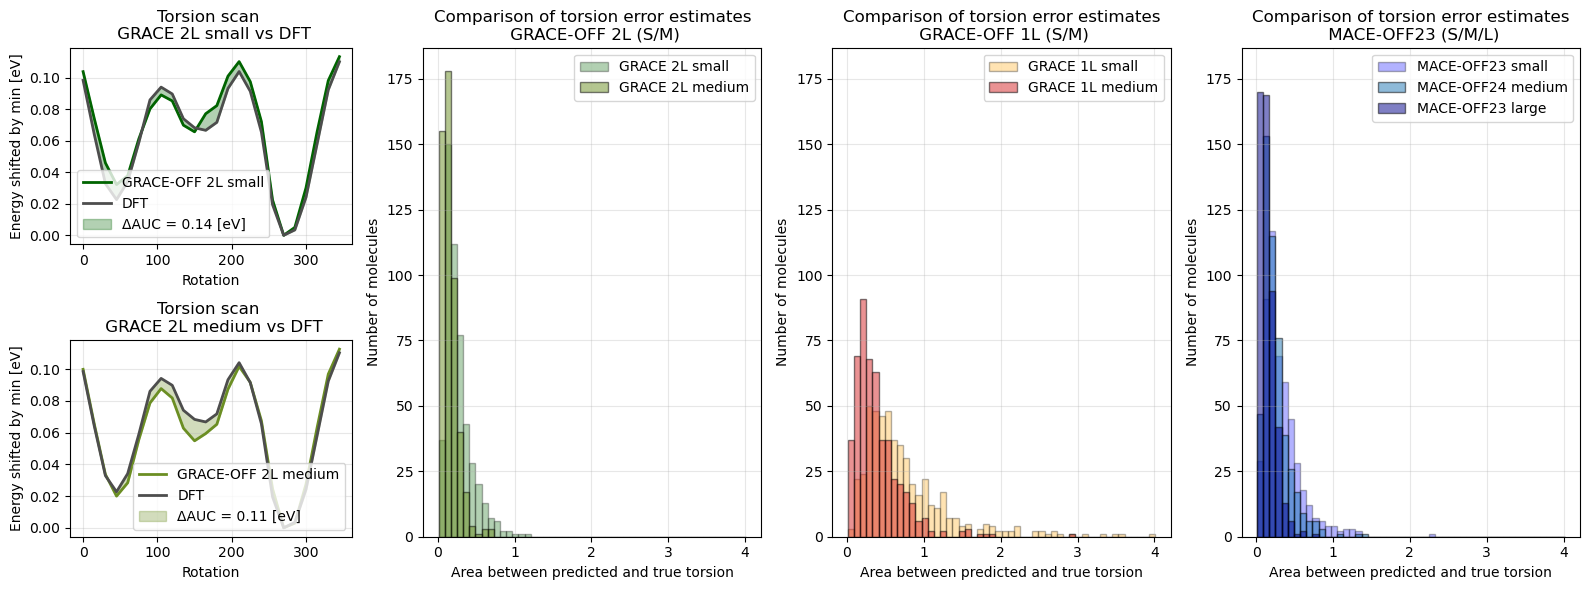

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Farben
color_small = "#006400"   # Blau
color_medium = "#6B8E23"  # Grün
color_dft = "#4d4d4d"     # Dunkelgrau
data_tnet = h5py.File("../../data/TNet500-SPICE.hdf5", "r")
smiles = list(data_tnet.keys())[0]



# Daten vorbereiten
# x = np.arange(len(torsion_energies_small))
torsion_small = np.asarray(single_torsion['small_2l']) - np.min(np.asarray(single_torsion['small_2l']))
torsion_med   = np.asarray(single_torsion['medium_2l']) - np.min(np.asarray(single_torsion['medium_2l']))
dft          = np.asarray(data_tnet[smiles]["dft total energy"]) * 27.211386245988
dft          = dft - np.min(dft)
x = np.arange(len(dft))

area_small = np.trapz(np.abs(torsion_small - dft), x)
area_medium= np.trapz(np.abs(torsion_med - dft), x)

x = np.arange(len(dft))*15

# Layout: 2 Zeilen, 2 Spalten, rechte Spalte breiter
fig = plt.figure(figsize=(16, 6))
gs = GridSpec(2, 4, figure=fig, width_ratios=[1, 1.2, 1.2, 1.2])

# --- Linke obere Hälfte: GRACE small vs DFT ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(x, torsion_small, color=color_small, label="GRACE-OFF 2L small", linewidth=2)
ax1.plot(x, dft, color=color_dft, label="DFT", linewidth=2)
ax1.fill_between(x, torsion_small, dft, color=color_small, alpha=0.3, label=f"ΔAUC = {area_small:.2f} [eV]")
ax1.set_xlabel("Rotation")
ax1.set_ylabel("Energy shifted by min [eV]")
ax1.set_title("Torsion scan \n GRACE 2L small vs DFT")
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Linke untere Hälfte: GRACE medium vs DFT ---
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(x, torsion_med, color=color_medium, label="GRACE-OFF 2L medium", linewidth=2)
ax2.plot(x, dft, color=color_dft, label="DFT", linewidth=2)  # gleiche Farbe wie oben
ax2.fill_between(x, torsion_med, dft, color=color_medium, alpha=0.3, label=f"ΔAUC = {area_medium:.2f} [eV]")
ax2.set_xlabel("Rotation")
ax2.set_ylabel("Energy shifted by min [eV]")
ax2.set_title("Torsion scan \n GRACE 2L medium vs DFT")
ax2.legend()
ax2.grid(True, alpha=0.3)


# Gemeinsame x-Achse für Histogramme
x_min = min(np.min(grace_errors_1l_off_s['AUC']), np.min(grace_errors_1l_off_m['AUC']),
            np.min(grace_errors_2l_off_s['AUC']), np.min(grace_errors_2l_off_m['AUC']))
x_max = max(np.max(grace_errors_1l_off_s['AUC']), np.max(grace_errors_1l_off_m['AUC']),
            np.max(grace_errors_2l_off_s['AUC']), np.max(grace_errors_2l_off_m['AUC']))

bar_width = 0.08  # Breite der Bars
bins = np.arange(x_min, x_max + bar_width, bar_width)  # Grenzen für alle Histogramme

# --- Rechte Seite (über beide Zeilen): Histogramm ---
ax3 = fig.add_subplot(gs[:, 1])
ax3.hist(grace_errors_2l_off_s['AUC'], bins=bins, color=color_small, edgecolor='black', alpha=0.3, label='GRACE 2L small')
ax3.hist(grace_errors_2l_off_m['AUC'], bins=bins, color=color_medium, edgecolor='black', alpha=0.5, label='GRACE 2L medium')
ax3.set_xlabel("Area between predicted and true torsion")
ax3.set_ylabel("Number of molecules")
ax3.set_title("Comparison of torsion error estimates\n GRACE-OFF 2L (S/M)")
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(gs[:, 2], sharex=ax3, sharey=ax3)
ax4.hist(grace_errors_1l_off_s['AUC'], bins=bins, color='orange', edgecolor='black', alpha=0.3, label='GRACE 1L small')
ax4.hist(grace_errors_1l_off_m['AUC'], bins=bins, color='tab:red', edgecolor='black', alpha=0.5, label='GRACE 1L medium')
ax4.set_xlabel("Area between predicted and true torsion")
ax4.set_ylabel("Number of molecules")
ax4.set_title("Comparison of torsion error estimates\n GRACE-OFF 1L (S/M)")
ax4.legend()
ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(gs[:, 3], sharex=ax3, sharey=ax3)
ax5.hist(mace_errors_s['AUC'], bins=bins, color='blue', edgecolor='black', alpha=0.3, label='MACE-OFF23 small')
ax5.hist(mace_errors_m['AUC'], bins=bins, color='tab:blue', edgecolor='black', alpha=0.5, label='MACE-OFF24 medium')
ax5.hist(mace_errors_l['AUC'], bins=bins, color='darkblue', edgecolor='black', alpha=0.5, label='MACE-OFF23 large')
ax5.set_xlabel("Area between predicted and true torsion")
ax5.set_ylabel("Number of molecules")
ax5.set_title("Comparison of torsion error estimates\n MACE-OFF23 (S/M/L)")
ax5.legend()
ax5.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [21]:


# Tabelle drucken
print('#'*100)
print(f"{'Model':<20} {'Mean AUC error [eV]':>16} {'Mean BH error [e-1eV]':>16} {'Mean BH absolute error [e-1eV]':>16}")
print('#'*100)

# GRACE wpS
print(f"{'GRACE wpS 1L small':<20} {round(grace_errors_1l_wps_s['AUC'].mean(),2):>16} {round(grace_errors_1l_wps_s['HB'].mean()*10,2):>16} {round(abs(grace_errors_1l_wps_s['HB']).mean()*10,2):>16}")
print(f"{'GRACE wpS 1L medium':<20} {round(grace_errors_1l_wps_m['AUC'].mean(),2):>16} {round(grace_errors_1l_wps_m['HB'].mean()*10,2):>16} {round(abs(grace_errors_1l_wps_m['HB']).mean()*10,2):>16}")
print(f"{'GRACE wpS 2L small':<20} {round(grace_errors_2l_wps_s['AUC'].mean(),2):>16} {round(grace_errors_2l_wps_s['HB'].mean()*10,2):>16} {round(abs(grace_errors_2l_wps_s['HB']).mean()*10,2):>16}")
print(f"{'GRACE wpS 2L medium':<20} {round(grace_errors_2l_wps_m['AUC'].mean(),2):>16} {round(grace_errors_2l_wps_m['HB'].mean()*10,2):>16} {round(abs(grace_errors_2l_wps_m['HB']).mean()*10,2):>16}")
print('#'*100)
# GRACE OFF
print(f"{'GRACE OFF 1L small':<20} {round(grace_errors_1l_off_s['AUC'].mean(),2):>16} {round(grace_errors_1l_off_s['HB'].mean()*10,2):>16} {round(abs(grace_errors_1l_off_s['HB']).mean()*10,2):>16}")
print(f"{'GRACE OFF 1L medium':<20} {round(grace_errors_1l_off_m['AUC'].mean(),2):>16} {round(grace_errors_1l_off_m['HB'].mean()*10,2):>16} {round(abs(grace_errors_1l_off_m['HB']).mean()*10,2):>16}")
print(f"{'GRACE OFF 1L large':<20} {round(grace_errors_1l_off_l['AUC'].mean(),2):>16} {round(grace_errors_1l_off_l['HB'].mean()*10,2):>16} {round(abs(grace_errors_1l_off_l['HB']).mean()*10,2):>16}")
print(f"{'GRACE OFF 2L small':<20} {round(grace_errors_2l_off_s['AUC'].mean(),2):>16} {round(grace_errors_2l_off_s['HB'].mean()*10,2):>16} {round(abs(grace_errors_2l_off_s['HB']).mean()*10,2):>16}")
print(f"{'GRACE OFF 2L medium':<20} {round(grace_errors_2l_off_m['AUC'].mean(),2):>16} {round(grace_errors_2l_off_m['HB'].mean()*10,2):>16} {round(abs(grace_errors_2l_off_m['HB']).mean()*10,2):>16}")
print(f"{'GRACE OFF 2L large':<20} {round(grace_errors_2l_off_l['AUC'].mean(),2):>16} {round(grace_errors_2l_off_l['HB'].mean()*10,2):>16} {round(abs(grace_errors_2l_off_l['HB']).mean()*10,2):>16}")
print('#'*100)
# MACE 
print(f"{'MACE-OFF23 small':<20} {round(mace_errors_s['AUC'].mean(),2):>16} {round(mace_errors_s['HB'].mean()*10,2):>16} {round(abs(mace_errors_s['HB']).mean()*10,2):>16}")
print(f"{'MACE-OFF23 medium':<20} {round(mace_errors_m['AUC'].mean(),2):>16} {round(mace_errors_m['HB'].mean()*10,2):>16} {round(abs(mace_errors_m['HB']).mean()*10,2):>16}")
print(f"{'MACE-OFF23 large':<20} {round(mace_errors_l['AUC'].mean(),2):>16} {round(mace_errors_l['HB'].mean()*10,2):>16} {round(abs(mace_errors_l['HB']).mean()*10,2):>16}")

print('#'*100)


####################################################################################################
Model                Mean AUC error [eV] Mean BH error [e-1eV] Mean BH absolute error [e-1eV]
####################################################################################################
GRACE wpS 1L small               1.35             0.35             0.82
GRACE wpS 1L medium              0.97             0.17             0.62
GRACE wpS 2L small                0.6            -0.04             0.41
GRACE wpS 2L medium              0.45             -0.1             0.31
####################################################################################################
GRACE OFF 1L small               0.75            -0.11             0.48
GRACE OFF 1L medium              0.39            -0.05             0.27
GRACE OFF 1L large               0.32            -0.09             0.22
GRACE OFF 2L small               0.26             -0.1             0.19
GRACE OFF 2L medium        

In [18]:
atom_energy = {
    "B": {-1: -24.677421752684776, 0: -24.671520535482145, 1: -24.364648707125294},
    "Br": {-1: -2574.2451510945853, 0: -2574.1167240829964},
    "C": {-1: -37.91424135791358, 0: -37.87264507233593, 1: -37.45349214963933},
    "Ca": {2: -676.9528465198214},
    "Cl": {-1: -460.3350243496703, 0: -460.1988762285739},
    "F": {-1: -99.91298732343974, 0: -99.78611622985483},
    "H": {-1: -0.5027370838721259, 0: -0.4987605100487531, 1: 0.0},
    "I": {-1: -297.8813829975981, 0: -297.76228914445625},
    "K": {1: -599.8025677513111},
    "Li": {1: -7.285254714046546},
    "Mg": {2: -199.2688420040449},
    "N": {-1: -54.602291095426494, 0: -54.62327513368922, 1: -54.08594142587869},
    "Na": {1: -162.11366478783253},
    "O": {-1: -75.17101657391741, 0: -75.11317840410095, 1: -74.60241514396725},
    "P": {0: -341.3059197024934, 1: -340.9258392474849},
    "S": {-1: -398.2405387031612, 0: -398.1599636677874, 1: -397.7746615977658},
    "Si": {-1: -289.4540686037408, 0: -289.4131352299586, 1: -289.1189404777897},
}

default_charge = {}
for symbol in atom_energy:
    energies = [(energy, charge) for charge, energy in atom_energy[symbol].items()]
    default_charge[symbol] = sorted(energies)[0][1]

def compute_reference_energy(smiles):
    rdmol = Chem.MolFromSmiles(smiles, sanitize=False)
    total_charge = sum(atom.GetFormalCharge() for atom in rdmol.GetAtoms())
    symbol = [atom.GetSymbol() for atom in rdmol.GetAtoms()]
    charge = [default_charge[s] for s in symbol]
    delta = np.sign(total_charge - sum(charge))
    while delta != 0:
        best_index = -1
        best_energy = None
        for i in range(len(symbol)):
            s = symbol[i]
            e = atom_energy[s]
            new_charge = charge[i] + delta
            if new_charge in e:
                if best_index == -1 or e[new_charge] - e[charge[i]] < best_energy:
                    best_index = i
                    best_energy = e[new_charge] - e[charge[i]]
        charge[best_index] += delta
        delta = np.sign(total_charge - sum(charge))
    return sum(atom_energy[s][c] for s, c in zip(symbol, charge))

In [19]:
model_path = "../models"
# Load data for different tests
# For torsion profiles
data_tnet = h5py.File("../data/TNet500-SPICE.hdf5", "r")
data_biaryl = h5py.File("../data/Biaryl-SPICE.hdf5", "r")

In [20]:
calc_grace_small = TPCalculator(
    model=f"{model_path}/2l/b_off_small/seed/1/saved_model/"
)
calc_grace_medium = TPCalculator(
    model=f"{model_path}/2l/b_off_medium/seed/1/saved_model/"
)
# calc_grace_large = TPCalculator(
#     model=f"{model_path}/2l/b_off_large/seed/1/saved_model/"
# )

calc_grace_small_1l = TPCalculator(
    model=f"{model_path}/1l/b_off_small/seed/1/saved_model/"
)
calc_grace_medium_1l = TPCalculator(
    model=f"{model_path}/1l/b_off_medium/seed/1/saved_model/"
)
# calc_grace_large_1l = TPCalculator(
#     model=f"{model_path}/1l/b_off_large/seed/1/saved_model/"
# )

calc_mace_large = MACECalculator(
    model_paths=f"{model_path}/MACE-OFF23_large.model", device="cuda"
)
calc_mace_medium = MACECalculator(
    model_paths=f"{model_path}/MACE-OFF24_medium.model", device="cuda"
)
calc_mace_small = MACECalculator(
    model_paths=f"{model_path}/MACE-OFF23_small.model", device="cuda"
)

/home/johannes.karwounopoulos/miniconda3/envs/ai-fennel/lib/python3.12/site-packages/mace/calculators/mace.py:197: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/home/johannes.karwounopoulos/miniconda3/envs/ai-fennel/lib/python3.12/site-packages/mace/calculators/mace.py:197: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/home/johannes.karwounopoulos/miniconda3/envs/ai-fennel/lib/python3.12/site-packages/mace/calculators/mace.py:197: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=m

Using head Default out of ['Default']
No dtype selected, switching to float64 to match model dtype.
Using head Default out of ['Default']
No dtype selected, switching to float64 to match model dtype.
Using head Default out of ['Default']
No dtype selected, switching to float64 to match model dtype.


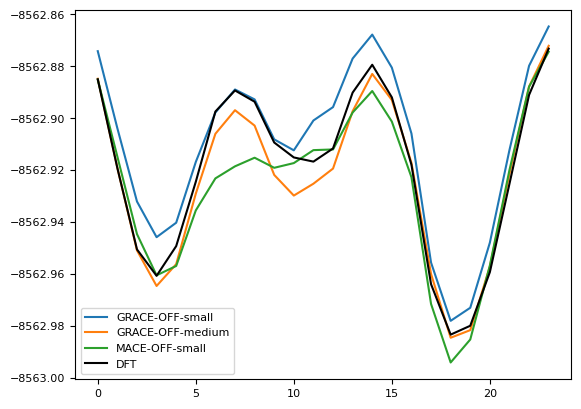

In [21]:
smiles = list(data_tnet.keys())[0]

Z = data_tnet[smiles]["atomic_numbers"][:]
symbols = [chemical_symbols[int(z)] for z in Z]

torsion_energies_small = []
torsion_energies_medium = []
torsion_energies_mace = []

for i, conf in enumerate(data_tnet[smiles]["conformations"]):
    pos = data_tnet[smiles]["conformations"][i][:] * units.Bohr
    mol = Atoms(symbols=symbols, positions=pos)
    mol.calc = calc_grace_small
    energy = mol.get_potential_energy()
    ref_energy = compute_reference_energy(smiles) * 27.211386245988
    torsion_energies_small.append(energy + ref_energy)

    mol.calc = calc_grace_medium
    energy = mol.get_potential_energy()
    ref_energy = compute_reference_energy(smiles) * 27.211386245988
    torsion_energies_medium.append(energy + ref_energy)

    mol.calc = calc_mace_small
    energy = mol.get_potential_energy()
    torsion_energies_mace.append(energy)

plt.plot(np.asarray(torsion_energies_small), label="GRACE-OFF-small")
plt.plot(np.asarray(torsion_energies_medium), label="GRACE-OFF-medium")
plt.plot(np.asarray(torsion_energies_mace), label="MACE-OFF-small")
plt.plot(data_tnet[smiles]["dft total energy"][:] * 27.211386245988, label="DFT", color="black")
plt.legend()

Fläche zwischen den Kurven = 0.137274 (in Energie·Index-Einheiten)


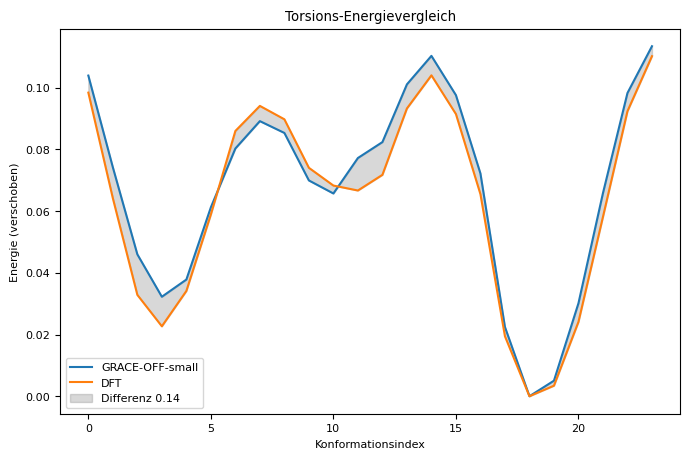

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Beispiel-Daten: n Punkte
x = np.arange(len(torsion_energies_small))

# Deine Kurven (auf gleicher x-Achse)
y1 = np.asarray(torsion_energies_small) - np.min(np.asarray(torsion_energies_small))
y2 = np.asarray(data_tnet[smiles]["dft total energy"]) * 27.211386245988
y2 = y2 - np.min(y2)

# Berechne Fläche zwischen den Kurven (Integral über |y1 - y2|)
area = np.trapz(np.abs(y1 - y2), x)

# Fläche zwischen den Kurven füllen
plt.figure(figsize=(8,5))
plt.plot(x, y1, label="GRACE-OFF-small")
plt.plot(x, y2, label="DFT")

# Bereich zwischen den Kurven füllen (komplett farbig)
plt.fill_between(x, y1, y2, color='gray', alpha=0.3, label=f"Differenz {round(area,2)}")

# Alternativ: strichlierte Fläche statt Füllung:
# plt.fill_between(x, y1, y2, color='none', hatch='//', edgecolor='gray', linewidth=0.0, alpha=0.5)

plt.legend()
plt.xlabel("Konformationsindex")
plt.ylabel("Energie (verschoben)")
plt.title("Torsions-Energievergleich")



print(f"Fläche zwischen den Kurven = {area:.6f} (in Energie·Index-Einheiten)")
plt.show()


In [ ]:
from tqdm import tqdm
import numpy as np
from ase import Atoms
from ase.data import chemical_symbols
from ase import units

def get_area_error_grace(small: bool, medium: bool, large: bool):
    error_trapez_grace_small = []
    error_trapez_grace_medium = []
    error_trapez_grace_large = []

    # tqdm über Moleküle
    for smiles in tqdm(data_tnet.keys(), desc="Berechne Fehlerflächen", unit="mol", ncols=80):
        Z = data_tnet[smiles]["atomic_numbers"][:]
        symbols = [chemical_symbols[int(z)] for z in Z]

        torsion_energies_small = []
        torsion_energies_medium = []
        torsion_energies_large = []

        # DFT-Referenzkurve
        dft_energy = np.asarray(data_tnet[smiles]["dft total energy"][:]) * 27.211386245988

        # Schleife über Konformationen
        for conf in data_tnet[smiles]["conformations"]:
            pos = conf[:] * units.Bohr
            mol = Atoms(symbols=symbols, positions=pos)

            if small:
                mol.calc = calc_grace_small
                torsion_energies_small.append(mol.get_potential_energy())

            if medium:
                mol.calc = calc_grace_medium
                torsion_energies_medium.append(mol.get_potential_energy())

            if large:
                mol.calc = calc_grace_large
                torsion_energies_large.append(mol.get_potential_energy())

        # Nach der Konformationsschleife: x-Achse erst jetzt definieren
        x = np.arange(len(dft_energy))

        if small and torsion_energies_small:
            grace_small_error = (np.array(torsion_energies_small) - np.min(torsion_energies_small)) - (dft_energy - np.min(dft_energy))
            area_small = np.trapezoid(np.abs(grace_small_error), x)
            error_trapez_grace_small.append(area_small)

        if medium and torsion_energies_medium:
            grace_medium_error = (np.array(torsion_energies_medium) - np.min(torsion_energies_medium)) - (dft_energy - np.min(dft_energy))
            area_medium = np.trapezoid(np.abs(grace_medium_error), x)
            error_trapez_grace_medium.append(area_medium)

        if large and torsion_energies_large:
            grace_large_error = (np.array(torsion_energies_large) - np.min(torsion_energies_large)) - (dft_energy - np.min(dft_energy))
            area_large = np.trapezoid(np.abs(grace_large_error), x)
            error_trapez_grace_large.append(area_large)

    return error_trapez_grace_small, error_trapez_grace_medium, error_trapez_grace_large


In [ ]:
from tqdm import tqdm
import numpy as np
from ase import Atoms
from ase.data import chemical_symbols
from ase import units

def get_area_error_mace(small: bool, medium: bool, large: bool):
    error_trapez_mace_small = []
    error_trapez_mace_medium = []
    error_trapez_mace_large = []

    # tqdm über Moleküle
    for smiles in tqdm(data_tnet.keys(), desc="Berechne Fehlerflächen", unit="mol", ncols=80):
        Z = data_tnet[smiles]["atomic_numbers"][:]
        symbols = [chemical_symbols[int(z)] for z in Z]

        torsion_energies_small = []
        torsion_energies_medium = []
        torsion_energies_large = []

        # DFT-Referenzkurve
        dft_energy = np.asarray(data_tnet[smiles]["dft total energy"][:]) * 27.211386245988

        # Schleife über Konformationen
        for conf in data_tnet[smiles]["conformations"]:
            pos = conf[:] * units.Bohr
            mol = Atoms(symbols=symbols, positions=pos)

            if small:
                mol.calc = calc_mace_small
                torsion_energies_small.append(mol.get_potential_energy())

            if medium:
                mol.calc = calc_mace_medium
                torsion_energies_medium.append(mol.get_potential_energy())

            if large:
                mol.calc = calc_mace_large
                torsion_energies_large.append(mol.get_potential_energy())

        # Nach der Konformationsschleife: x-Achse erst jetzt definieren
        x = np.arange(len(dft_energy))

        if small and torsion_energies_small:
            mace_small_error = (np.array(torsion_energies_small) - np.min(torsion_energies_small)) - (dft_energy - np.min(dft_energy))
            area_small = np.trapezoid(np.abs(mace_small_error), x)
            error_trapez_mace_small.append(area_small)

        if medium and torsion_energies_medium:
            mace_medium_error = (np.array(torsion_energies_medium) - np.min(torsion_energies_medium)) - (dft_energy - np.min(dft_energy))
            area_medium = np.trapezoid(np.abs(mace_medium_error), x)
            error_trapez_mace_medium.append(area_medium)

        if large and torsion_energies_large:
            mace_large_error = (np.array(torsion_energies_large) - np.min(torsion_energies_large)) - (dft_energy - np.min(dft_energy))
            area_large = np.trapezoid(np.abs(mace_large_error), x)
            error_trapez_mace_large.append(area_large)

    return error_trapez_mace_small, error_trapez_mace_medium, error_trapez_mace_large


In [16]:
error_trapez_grace_small, error_trapez_grace_medium, _ = get_area_error_grace(True, True, False)

Berechne Fehlerflächen:   0%|                          | 0/500 [00:00<?, ?mol/s]


AttributeError: module 'numpy' has no attribute 'trapez'

In [ ]:
error_trapez_mace_small, error_trapez_mace_medium, _ = get_area_error_mace(True, True, False)

In [ ]:
_, _, error_trapez_mace_large = get_area_error_mace(False, False, True)

In [ ]:
def get_single_torsion(index, small: bool, medium: bool):

    smiles = list(data_tnet.keys())[index]
    Z = data_tnet[smiles]["atomic_numbers"][:]
    symbols = [chemical_symbols[int(z)] for z in Z]

    torsion_energies_small = []
    torsion_energies_medium = []

    for i, conf in enumerate(data_tnet[smiles]["conformations"]):
        pos = data_tnet[smiles]["conformations"][i][:] * units.Bohr
        mol = Atoms(symbols=symbols, positions=pos)
        if small:
            mol.calc = calc_grace_small
            energy = mol.get_potential_energy()
            torsion_energies_small.append(energy)
        if medium:
            mol.calc = calc_grace_medium
            energy = mol.get_potential_energy()
            torsion_energies_medium.append(energy)

    return torsion_energies_small, torsion_energies_medium

In [ ]:
torsion_energies_small, torsion_energies_medium = get_single_torsion(0, True, True)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Farben
color_small = "#1f77b4"   # Blau
color_medium = "#2ca02c"  # Grün
color_dft = "#4d4d4d"     # Dunkelgrau

# Daten vorbereiten
x = np.arange(len(torsion_energies_small))
torsion_small = np.asarray(torsion_energies_small) - np.min(np.asarray(torsion_energies_small))
torsion_med   = np.asarray(torsion_energies_medium) - np.min(np.asarray(torsion_energies_medium))
dft          = np.asarray(data_tnet[smiles]["dft total energy"]) * 27.211386245988
dft          = dft - np.min(dft)

area_small = np.trapz(np.abs(torsion_small - dft), x)
area_medium= np.trapz(np.abs(torsion_med - dft), x)



# Layout: 2 Zeilen, 2 Spalten, rechte Spalte breiter
fig = plt.figure(figsize=(14, 6))
gs = GridSpec(2, 3, figure=fig, width_ratios=[1, 1.4, 1.4])

# --- Linke obere Hälfte: GRACE small vs DFT ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(x, torsion_small, color=color_small, label="GRACE-OFF small", linewidth=2)
ax1.plot(x, dft, color=color_dft, label="DFT", linewidth=2)
ax1.fill_between(x, torsion_small, dft, color=color_small, alpha=0.3, label=f"ΔAUC = {area_small:.2f} [eV]")
ax1.set_xlabel("Rotation")
ax1.set_ylabel("Energy shifted by min [eV]")
ax1.set_title("Torsion scan – GRACE small vs DFT")
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Linke untere Hälfte: GRACE medium vs DFT ---
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(x, torsion_med, color=color_medium, label="GRACE-OFF medium", linewidth=2)
ax2.plot(x, dft, color=color_dft, label="DFT", linewidth=2)  # gleiche Farbe wie oben
ax2.fill_between(x, torsion_med, dft, color=color_medium, alpha=0.3, label=f"ΔAUC = {area_medium:.2f} [eV]")
ax2.set_xlabel("Rotation")
ax2.set_ylabel("Energy shifted by min [eV]")
ax2.set_title("Torsion scan – GRACE medium vs DFT")
ax2.legend()
ax2.grid(True, alpha=0.3)


# Gemeinsame x-Achse für Histogramme
x_min = min(np.min(error_trapez_grace_small), np.min(error_trapez_grace_medium),
            np.min(error_trapez_mace_small), np.min(error_trapez_mace_medium))
x_max = max(np.max(error_trapez_grace_small), np.max(error_trapez_grace_medium),
            np.max(error_trapez_mace_small), np.max(error_trapez_mace_medium))

bar_width = 0.08  # Breite der Bars
bins = np.arange(x_min, x_max + bar_width, bar_width)  # Grenzen für alle Histogramme

# --- Rechte Seite (über beide Zeilen): Histogramm ---
ax3 = fig.add_subplot(gs[:, 1])
ax3.hist(error_trapez_grace_small, bins=bins, color=color_small, edgecolor='black', alpha=0.3, label='GRACE small')
ax3.hist(error_trapez_grace_medium, bins=bins, color=color_medium, edgecolor='black', alpha=0.5, label='GRACE medium')
ax3.set_xlabel("Area between predicted and true torsion")
ax3.set_ylabel("Number of molecules")
ax3.set_title("Comparison of torsion error estimates\n GRACE-OFF small and GRACE-OFF medium")
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(gs[:, 2], sharex=ax3, sharey=ax3)
ax4.hist(error_trapez_mace_small, bins=bins, color='orange', edgecolor='black', alpha=0.3, label='MACE small')
ax4.hist(error_trapez_mace_medium, bins=bins, color='tab:red', edgecolor='black', alpha=0.5, label='MACE medium')
ax4.hist(error_trapez_mace_large, bins=bins, color='yellow', edgecolor='black', alpha=0.5, label='MACE large')
ax4.set_xlabel("Area between predicted and true torsion")
ax4.set_ylabel("Number of molecules")
ax4.set_title("Comparison of torsion error estimates\n MACE-OFF23 small and MACE-OFF23 medium")
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np

# -------------------------
# GRACE-Daten
# -------------------------
grace_dict = {
    "small": error_trapez_grace_small,
    "medium": error_trapez_grace_medium
    # large fehlt hier, wird ignoriert
}

# in DataFrame umwandeln
df_grace = pd.DataFrame(dict([(k, pd.Series(v)) for k,v in grace_dict.items()]))

# CSV speichern
df_grace.to_csv("grace_errors.csv", index=False)
print("GRACE errors saved to grace_errors.csv")

# -------------------------
# MACE-Daten
# -------------------------
mace_dict = {
    "small": error_trapez_mace_small,
    "medium": error_trapez_mace_medium,
    "large": error_trapez_mace_large
}

# DataFrame
df_mace = pd.DataFrame(dict([(k, pd.Series(v)) for k,v in mace_dict.items()]))

# CSV speichern
df_mace.to_csv("mace_errors.csv", index=False)
print("MACE errors saved to mace_errors.csv")


In [ ]:
## Models to investigate
# MACE models for comparison
calc_mace_large = MACECalculator(
    model_paths=f"{model_path}/MACE-OFF23_large.model", device="cuda"
)
calc_mace_medium = MACECalculator(
    model_paths=f"{model_path}/MACE-OFF24_medium.model", device="cuda"
)
calc_mace_small = MACECalculator(
    model_paths=f"{model_path}/MACE-OFF23_small.model", device="cuda"
)
# GRACE models
calc_grace_small = TPCalculator(
    model="/share/theochem/johannes.karwounopoulos/4d_test/train_grace/1_layer/b_off_small/seed/1/saved_model/"
)
# calc_grace_medium = TPCalculator(
#     model="/share/theochem/johannes.karwounopoulos/4d_test/train_grace/1_layer/b_off_medium/seed/1/saved_model/"
# )
# calc_grace_large = TPCalculator(
#     model="/share/theochem/johannes.karwounopoulos/4d_test/train_grace/2_layer/a_wpS_large/seed/1/saved_model/"
# )

In [ ]:
def calculate_energies_for_torsions(data):

    # diff_mace_large = []
    # diff_mace_medium = []
    # diff_mace_small = []
    diff_grace_small = []
    diff_grace_medium = []
    # diff_grace_large = []

    keys = list(data) 
    sample_keys = random.sample(keys, 5)

    for key in tqdm.tqdm(list(data.keys())):  # list(data.keys())

        Z = data[key]["atomic_numbers"][:]
        symbols = [chemical_symbols[int(z)] for z in Z]
        dft_energies = data[key]["dft total energy"][:] * 27.211386245988
        dft_energies = [e - min(dft_energies) for e in dft_energies]

        # energies_mace_large = []
        # energies_mace_medium = []
        # energies_mace_small = []
        energies_grace_small = []
        energies_grace_medium = []
        # energies_grace_large = []

        for i in range(len(data[key]["conformations"])):
            pos = data[key]["conformations"][i][:] * units.Bohr
            mol = Atoms(symbols=symbols, positions=pos)

            # mol.calc = calc_mae_large
            # e = mol.get_potential_energy()
            # energies_mace_large.append(e)

            # mol.calc = calc_mace_medium
            # e = mol.get_potential_energy()
            # energies_mace_medium.append(e)

            # mol.calc = calc_mace_small
            # e = mol.get_potential_energy()
            # energies_mace_small.append(e)

            mol.calc = calc_grace_small
            e = mol.get_potential_energy()
            energies_grace_small.append(e)

            mol.calc = calc_grace_medium
            e = mol.get_potential_energy()
            energies_grace_medium.append(e)

            # mol.calc = calc_grace_large
            # e = mol.get_potential_energy()
            # energies_grace_large.append(e)

        # energies_mace_large = [
        #     e - min(energies_mace_large) for e in energies_mace_large
        # ]
        # energies_mace_medium = [
        #     e - min(energies_mace_medium) for e in energies_mace_medium
        # ]
        # energies_mace_small = [
        #     e - min(energies_mace_small) for e in energies_mace_small
        # ]
        energies_grace_small = [
            e - min(energies_grace_small) for e in energies_grace_small
        ]
        energies_grace_medium = [
            e - min(energies_grace_medium) for e in energies_grace_medium
        ]
        # energies_grace_large = [
        #     e - min(energies_grace_large) for e in energies_grace_large
        # ]

        # diff_mace_large.append(
        #     np.mean(np.asarray(energies_mace_large) - np.asarray(dft_energies))
        # )
        # diff_mace_medium.append(
        #     np.mean(np.asarray(energies_mace_medium) - np.asarray(dft_energies))
        # )
        # diff_mace_small.append(
        #     np.mean(np.asarray(energies_mace_small) - np.asarray(dft_energies))
        # )
        diff_grace_small.append(
            np.mean(np.asarray(energies_grace_small) - np.asarray(dft_energies))
        )
        diff_grace_medium.append(
            np.mean(np.asarray(energies_grace_medium) - np.asarray(dft_energies))
        )
        # diff_grace_large.append(
        #     np.mean(np.asarray(energies_grace_large) - np.asarray(dft_energies))
        # )
        

    # print("MACE large modell:", round(np.mean(np.abs(diff_mace_large)), 3))
    # print("MACE medium modell:", round(np.mean(np.abs(diff_mace_medium)), 3))
    # print("MACE small modell:", round(np.mean(np.abs(diff_mace_small)), 3))
    print("Mod Grace modell:", round(np.mean(np.abs(diff_grace_small)), 3))
    print("Mod Grace medium modell:", round(np.mean(np.abs(diff_grace_medium)), 3))
    # print("Mod Grace large modell:", round(np.mean(np.abs(diff_grace_large)), 3))

    # Write results to CSV file
    results_df = pd.DataFrame(
        {
            "Model": [
                # "MACE large",
                # "MACE medium",
                # "MACE small",
                "GRACE small",
                "GRACE medium",
                # "GRACE large",
            ],
            "MAE_eV": [
                # np.mean(np.abs(diff_mace_large)),
                # np.mean(np.abs(diff_mace_medium)),
                # np.mean(np.abs(diff_mace_small)),
                np.mean(np.abs(diff_grace_small)),
                np.mean(np.abs(diff_grace_medium)),
                # np.mean(np.abs(diff_grace_large)),
            ],
        }
    )
    results_df.to_csv(f"{experiment}/torsion_energies_results_{data.filename.split('/')[-1].split('.')[0]}.csv", index=False)

    # plt.bar(
    #     ["MACE large", "MACE medium", "MACE small", "GRACE small", "GRACE medium"],
    #     [
    #         np.mean(np.abs(diff_mace_large)),
    #         np.mean(np.abs(diff_mace_medium)),
    #         np.mean(np.abs(diff_mace_small)),
    #         np.mean(np.abs(diff_grace_small)),
    #         np.mean(np.abs(diff_grace_medium)),
    #     ],
    # )
    # plt.ylabel("MAE [eV]")
    # # plt.yscale("log")
    # plt.show()

    return (
        # diff_mace_large,
        # diff_mace_medium,
        # diff_mace_small,
        diff_grace_small,
        diff_grace_medium,
        # diff_grace_large,
    )


def plot_bar_chart(
    diff_mace_large,
    diff_mace_medium,
    diff_mace_small,
    diff_grace_small,
    diff_grace_medium,
    # diff_grace_large,
    data,
):
    sns.set_theme(style="white")

    mae_vals = [
        np.mean(np.abs(diff_mace_large)),
        # np.mean(np.abs(diff_grace_large)),        
        np.mean(np.abs(diff_mace_medium)),
        np.mean(np.abs(diff_grace_medium)),
        np.mean(np.abs(diff_mace_small)),
        np.mean(np.abs(diff_grace_small)),  
    ]

    labels = [
        "MACE\nlarge",
        "GRACE\nlarge",
        "MACE\nmedium",
        "GRACE\nmedium",
        "MACE\nsmall",
        "GRACE\nsmall",
    ]
    families = ["MACE", "GRACE", "MACE", "GRACE", "MACE", "GRACE"]

    df = pd.DataFrame({"Model": labels, "MAE_eV": mae_vals, "Architecture": families})

    # Same color for all MACE bars and same for all GRACE bars
    palette = {
        "MACE": sns.color_palette("deep")[0],
        "GRACE": sns.color_palette("deep")[2],
    }

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.barplot(
        data=df,
        x="Model",
        y="MAE_eV",
        hue="Architecture",
        dodge=False,
        palette=palette,
        ax=ax,
    )

    ax.set_ylabel("MAE [eV]")
    ax.set_xlabel("")
    ax.set_xticklabels(ax.get_xticklabels(), ha="center")

    plt.legend(frameon=True)
    plt.tight_layout()
    plt.savefig(f"{experiment}/torsion_energies_bar_chart_{data.filename.split('/')[-1].split('.')[0]}.png", dpi=300)
    plt.show()

In [ ]:
(
    # diff_mace_large,
    # diff_mace_medium,
    # diff_mace_small,
    diff_grace_small,
    diff_grace_medium,
    diff_grace_large,
) = calculate_energies_for_torsions(data_tnet)

# Data for Tnet500
diff_mace_small = 0.010900202681683747
diff_mace_medium = 0.00832633049590034
diff_mace_large = 0.004945196822494154

plot_bar_chart(
    diff_mace_large,
    diff_mace_medium,
    diff_mace_small,
    diff_grace_small,
    diff_grace_medium,
    diff_grace_large,
    data_tnet,
)

(
    # diff_mace_large,
    # diff_mace_medium,
    # diff_mace_small,
    diff_grace_small,
    diff_grace_medium,
    diff_grace_large,
) = calculate_energies_for_torsions(data_biaryl)

diff_mace_small = 0.007679090306856489
diff_mace_medium = 0.00591374014346839
diff_mace_large = 0.002914610214596471

plot_bar_chart(
    diff_mace_large,
    diff_mace_medium,
    diff_mace_small,
    diff_grace_small,
    diff_grace_medium,
    diff_grace_large,
    data_biaryl,
)

In [ ]:
def calculate_energies_and_forces(calc, structures, ref_structures, model):

    pred_energies = []
    ref_energies = []
    pred_forces = []
    ref_forces = []

    for i, struc in enumerate(tqdm.tqdm(structures)):
        if model =="MACE":
            struc.calc = calc
            pred_energies.append(struc.get_potential_energy())
            ref_energies.append(ref_structures[i].info["total_energy"])

        else:
            struc.calc = calc
            pred_energies.append(struc.get_potential_energy())
            ref_energies.append(ref_structures[i].get_potential_energy())

        pred_forces.append(struc.get_forces().flatten())
        ref_forces.append(ref_structures[i].get_forces().flatten())

    return (
        pred_energies,
        ref_energies,
        pred_forces,
        ref_forces,
    )

In [ ]:
pred_energies_small, ref_energies_small, pred_forces_small, ref_forces_small = (
    calculate_energies_and_forces(calc_grace_small, structures, ref_structures, model="GRACE")
)
pred_energies_medium, ref_energies_medium, pred_forces_medium, ref_forces_medium = (
    calculate_energies_and_forces(calc_grace_medium, structures, ref_structures, model="GRACE")
)
pred_energies_large, ref_energies_large, pred_forces_large, ref_forces_large = (
    calculate_energies_and_forces(calc_grace_large, structures, ref_structures, model="GRACE")
)

In [ ]:
pred_energies_small, ref_energies_small, pred_forces_small, ref_forces_small = (
    calculate_energies_and_forces(calc_mace_small, structures, ref_structures, model="MACE")
)
pred_energies_medium, ref_energies_medium, pred_forces_medium, ref_forces_medium = (
    calculate_energies_and_forces(calc_mace_medium, structures, ref_structures, model="MACE")
)
pred_energies_large, ref_energies_large, pred_forces_large, ref_forces_large = (
    calculate_energies_and_forces(calc_mace_large, structures, ref_structures, model="MACE")
)

In [ ]:
# Create subplot with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3.5))

# Energy plot (left subplot)
ax1.scatter(ref_energies_small, pred_energies_small, s=1)
ax1.scatter(
    ref_energies_medium,
    pred_energies_medium,
    s=1,
    alpha=0.5,
    color="orange",
    marker="x",
)
ax1.scatter(
    ref_energies_large,
    pred_energies_large,
    s=1,
    alpha=0.5,
    color="green",
    marker="^",
)

# Calculate R² score
r2_small = r2_score(ref_energies_small, pred_energies_small)
r2_medium = r2_score(ref_energies_medium, pred_energies_medium)
r2_large = r2_score(ref_energies_large, pred_energies_large)

# Add text box with R² score
ax1.text(
    0.05,
    0.95,
    f"R²(s) = {r2_small:.7f}\nR²(m) = {r2_medium:.7f}\nR²(l) = {r2_large:.7f}",
    transform=ax1.transAxes,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    verticalalignment="top",
)

# Add dashed black diagonal line x=y
min_val = min(min(ref_energies_small), min(pred_energies_small))
max_val = max(max(ref_energies_small), max(pred_energies_small))
ax1.plot([min_val, max_val], [min_val, max_val], "k--", alpha=0.7)

# Add axis labels
ax1.set_xlabel("Reference Energies [eV]")
ax1.set_ylabel("Predicted Energies [eV]")
ax1.set_title("Energy Predictions")

print("Energies (s):", r2_small)
print("Energies (m):", r2_medium)
print("Energies (l):", r2_large)

# Forces plot (right subplot)
ref_forces_flat_small = np.concatenate(ref_forces_small).astype(float).tolist()
pred_forces_flat_small = np.concatenate(pred_forces_small).astype(float).tolist()

ref_forces_flat_medium = np.concatenate(ref_forces_medium).astype(float).tolist()
pred_forces_flat_medium = np.concatenate(pred_forces_medium).astype(float).tolist()

ref_forces_flat_large = np.concatenate(ref_forces_large).astype(float).tolist()
pred_forces_flat_large = np.concatenate(pred_forces_large).astype(float).tolist()

ax2.scatter(ref_forces_flat_small, pred_forces_flat_small, s=1, label="small")
ax2.scatter(
    ref_forces_flat_medium,
    pred_forces_flat_medium,
    s=1,
    alpha=0.5,
    color="orange",
    marker="x",
    label="medium",
)
ax2.scatter(
    ref_forces_flat_large,
    pred_forces_flat_large,
    s=1,
    alpha=0.5,
    color="green",
    marker="^",
    label="large",
)

# Calculate R² score for forces
r2_forces_small = r2_score(ref_forces_flat_small, pred_forces_flat_small)
r2_forces_medium = r2_score(ref_forces_flat_medium, pred_forces_flat_medium)
r2_forces_large = r2_score(ref_forces_flat_large, pred_forces_flat_large)

# Add text box with R² score
ax2.text(
    0.05,
    0.95,
    f"R²(s) = {r2_forces_small:.4f}\nR²(m) = {r2_forces_medium:.4f}\nR²(l) = {r2_forces_large:.4f}",
    transform=ax2.transAxes,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    verticalalignment="top",
)

# Add dashed black diagonal line x=y
min_val = min(min(ref_forces_flat_small), min(pred_forces_flat_small))
max_val = max(max(ref_forces_flat_small), max(pred_forces_flat_small))
ax2.plot([min_val, max_val], [min_val, max_val], "k--", alpha=0.7)

# Add axis labels
ax2.set_xlabel("Reference Forces [eV/Å]")
ax2.set_ylabel("Predicted Forces [eV/Å]")
ax2.legend(loc="lower right")
ax2.set_title("Force Predictions")

print("Forces (s):", r2_forces_small)
print("Forces (m):", r2_forces_medium)
print("Forces (l):", r2_forces_large)

plt.tight_layout()
plt.savefig(f"{experiment}/energies_forces_scatter.png", dpi=300)
plt.show()

In [ ]:
# Calculate MSE and RMSE for energies
mse_small_energy = mean_squared_error(ref_energies_small, pred_energies_small)
rmse_small_energy = root_mean_squared_error(ref_energies_small, pred_energies_small)
mse_medium_energy = mean_squared_error(ref_energies_medium, pred_energies_medium)
rmse_medium_energy = root_mean_squared_error(ref_energies_medium, pred_energies_medium)
mse_large_energy = mean_squared_error(ref_energies_large, pred_energies_large)
rmse_large_energy = root_mean_squared_error(ref_energies_large, pred_energies_large)
# Calculate MSE und RMSE for forces
mse_small_forces = mean_squared_error(ref_forces_flat_small, pred_forces_flat_small)
rmse_small_forces = root_mean_squared_error(
    ref_forces_flat_small, pred_forces_flat_small
)
mse_medium_forces = mean_squared_error(ref_forces_flat_medium, pred_forces_flat_medium)
rmse_medium_forces = root_mean_squared_error(
    ref_forces_flat_medium, pred_forces_flat_medium
)
mse_large_forces = mean_squared_error(ref_forces_flat_large, pred_forces_flat_large)
rmse_large_forces = root_mean_squared_error(
    ref_forces_flat_large, pred_forces_flat_large
)
# Print results
print("Energies")
print("Small model - MSE energy:", round(mse_small_energy, 4))
print("Medium model - MSE energy:", round(mse_medium_energy, 4))
print("Large model - MSE energy:", round(mse_large_energy, 4))
print("Small model - RMSE energy:", round(rmse_small_energy, 4))
print("Medium model - RMSE energy:", round(rmse_medium_energy, 4))
print("Large model - RMSE energy:", round(rmse_large_energy, 4))
print("Forces")
print("Small model - MSE forces:", round(mse_small_forces, 4))
print("Medium model - MSE forces:", round(mse_medium_forces, 4))
print("Large model - MSE forces:", round(mse_large_forces, 4))
print("Small model - RMSE forces:", round(rmse_small_forces, 4))
print("Medium model - RMSE forces:", round(rmse_medium_forces, 4))
print("Large model - RMSE forces:", round(rmse_large_forces, 4))

# Write results to CSV file
metrics_df = pd.DataFrame(
    {
        "Model": ["GRACE small", "GRACE medium", "GRACE large"],
        "MSE_Energy": [mse_small_energy, mse_medium_energy, mse_large_energy],
        "RMSE_Energy": [rmse_small_energy, rmse_medium_energy, rmse_large_energy],
        "MSE_Forces": [mse_small_forces, mse_medium_forces, mse_large_forces],
        "RMSE_Forces": [rmse_small_forces, rmse_medium_forces, rmse_large_forces],
    }
)
metrics_df.to_csv(f"{experiment}/energy_force_metrics.csv", index=False)

In [ ]:
n_atoms_list = []
per_atom_energy_errors_small = []
per_atom_energy_errors_medium = []
per_atom_energy_errors_large = []

for i, struc in enumerate(tqdm.tqdm(structures)):
    try:
        n = len(struc)
        n_atoms_list.append(n)

        per_atom_energy_errors_small.append(
            abs(ref_energies_small[i] - pred_energies_small[i]) / n
        )
        per_atom_energy_errors_medium.append(
            abs(ref_energies_medium[i] - pred_energies_medium[i]) / n
        )
        per_atom_energy_errors_large.append(
            abs(ref_energies_large[i] - pred_energies_large[i]) / n
        )
    except:
        continue

print("Per Atom error (small) in meV: ", np.sqrt(np.mean(np.asarray(per_atom_energy_errors_small) ** 2)) * 1000)
print("Per Atom error (medium) in meV: ", np.sqrt(np.mean(np.asarray(per_atom_energy_errors_medium) ** 2)) * 1000)
print("Per Atom error (large) in meV: ", np.sqrt(np.mean(np.asarray(per_atom_energy_errors_large) ** 2)) * 1000)

# Save per-atom error results to CSV
per_atom_rmse_small = np.sqrt(np.mean(np.asarray(per_atom_energy_errors_small) ** 2)) * 1000
per_atom_rmse_medium = np.sqrt(np.mean(np.asarray(per_atom_energy_errors_medium) ** 2)) * 1000
per_atom_rmse_large = np.sqrt(np.mean(np.asarray(per_atom_energy_errors_large) ** 2)) * 1000

per_atom_df = pd.DataFrame({
    "Model": ["GRACE small", "GRACE medium", "GRACE large"],
    "Per_Atom_RMSE_meV": [per_atom_rmse_small, per_atom_rmse_medium, per_atom_rmse_large]
})
per_atom_df.to_csv(f"{experiment}/per_atom_energy_errors.csv", index=False)